In [255]:
from data_utils import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KDTree
import time
import math
from scipy import linalg

%matplotlib inline

np.random.seed(0)

In [245]:
#Function is used to perform regression for k-NN using an L1 similarity metric
def knn_l1_regression(x_train, y_train, x_test, k=5):
    dist = np.sum(np.abs(x_train-x_test), axis=1) #l1 norm
    i_nn = np.argpartition(dist, kth=k)[:k] #Find k-NN
    y_result = np.average(y_train[i_nn]) #Average y values of k-NN
    return y_result

In [137]:
#Function is used to perform regression for k-NN using an L2 similarity metric
def knn_l2_regression(x_train, y_train, x_test, k=5):
    dist = np.sqrt(np.sum(np.square(x_train-x_test), axis=1)) #l2 norm
    i_nn = np.argpartition(dist, kth=k)[:k] #Find k-NN
    y_result = np.average(y_train[i_nn]) #Average y values of k-NN
    return y_result

In [301]:
#Used for Q1

#Function prints the similarity metric, optimal k and cross-validation RMSE for the best cross-validation RMSE
#Function prints the cross-validation RMSE for each similarity metric at each value of k
#Function also plots cross-validation RMSE over k

#To use, input data set and set the bounds for k to check over.

def regression(x_train, x_valid, x_test, y_train, y_valid, y_test, k_lower_bound, k_upper_bound):
    
    #Shuffle the training data
    
    features = len(x_train[0])
    
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    train_set = np.hstack([x_train, y_train])
    np.random.shuffle(train_set)
    
    x_train = train_set[:,:features]
    y_train = train_set[:,features:]
    
    dataset_length = len(x_train)

    l = int(math.floor(len(x_train)/5))

    #Split the training data into 5 splits
    xfold_1 = x_train[0:int(l-1)]
    xfold_2 = x_train[int(l):int(2*l-1)]
    xfold_3 = x_train[int(2*l):int(3*l-1)]
    xfold_4 = x_train[int(3*l):int(4*l-1)]
    xfold_5 = x_train[int(4*l):]

    yfold_1 = y_train[0:int(l-1)]
    yfold_2 = y_train[int(l):int(2*l-1)]
    yfold_3 = y_train[int(2*l):int(3*l-1)]
    yfold_4 = y_train[int(3*l):int(4*l-1)]
    yfold_5 = y_train[int(4*l):]

    #Store all 5 splits in a single list
    xfolds = [xfold_1,xfold_2,xfold_3,xfold_4,xfold_5]
    yfolds = [yfold_1,yfold_2,yfold_3,yfold_4,yfold_5]

    #Create training data for all 5 cross-validation splits
    xbatch_1 = np.concatenate((xfold_2,xfold_3,xfold_4,xfold_5),axis=0)
    xbatch_2 = np.concatenate((xfold_1,xfold_3,xfold_4,xfold_5),axis=0)
    xbatch_3 = np.concatenate((xfold_1,xfold_2,xfold_4,xfold_5),axis=0)
    xbatch_4 = np.concatenate((xfold_1,xfold_2,xfold_3,xfold_5),axis=0)
    xbatch_5 = np.concatenate((xfold_1,xfold_2,xfold_3,xfold_4),axis=0)

    ybatch_1 = np.concatenate((yfold_2,yfold_3,yfold_4,yfold_5),axis=0)
    ybatch_2 = np.concatenate((yfold_1,yfold_3,yfold_4,yfold_5),axis=0)
    ybatch_3 = np.concatenate((yfold_1,yfold_2,yfold_4,yfold_5),axis=0)
    ybatch_4 = np.concatenate((yfold_1,yfold_2,yfold_3,yfold_5),axis=0)
    ybatch_5 = np.concatenate((yfold_1,yfold_2,yfold_3,yfold_4),axis=0)

    #Store all sets of training data in a single list
    xbatches = [xbatch_1,xbatch_2,xbatch_3,xbatch_4,xbatch_5]
    ybatches = [ybatch_1,ybatch_2,ybatch_3,ybatch_4,ybatch_5]

    l1_losses = []
    l2_losses = []

    for k in range(k_lower_bound,k_upper_bound): #Loop through k values
        print("Iteration: k = " + str(k))
        l1_RMSEs = []
        l2_RMSEs = []
        for i in range(0,5): #Loop through all 5 cross-validation models

            #Set training and test sets for a particular cross-validation model
            x_train_batch = xbatches[i]
            y_train_batch = ybatches[i]
            x_test_batch = xfolds[i]
            y_test_batch = np.squeeze(yfolds[i])

            n = 0
            l1_total_loss = 0
            l2_total_loss = 0


            for j in x_test_batch: #Loop through all data points in the test set

                #Use l1 and l2 regression to get predictions for each point in the test set
                l1_y_result = knn_l1_regression(x_train_batch, y_train_batch, j, k)
                l2_y_result = knn_l2_regression(x_train_batch, y_train_batch, j, k)

                #Get squared error of result
                l1_total_loss += np.square(y_test_batch[n] - l1_y_result)
                l2_total_loss += np.square(y_test_batch[n] - l2_y_result)

                n+=1

            #Get RMSE for the particular cross-validation model   
            l1_RMSE = np.sqrt(l1_total_loss/len(x_test_batch))
            l2_RMSE = np.sqrt(l2_total_loss/len(x_test_batch))

            #Store RMSE for all 5 cross-validation models
            l1_RMSEs = l1_RMSEs + [l1_RMSE]
            l2_RMSEs = l2_RMSEs + [l2_RMSE]

        #Calculate average RMSE over all 5 cross-validation models
        l1_RMSE_avg = np.average(l1_RMSEs) 
        l2_RMSE_avg = np.average(l2_RMSEs)

        print("L1 RMSE: " + str(l1_RMSE_avg))
        print("L2 RMSE: " + str(l2_RMSE_avg))

        #Store average RMSE for all k values
        l1_losses = l1_losses + [l1_RMSE_avg]
        l2_losses = l2_losses + [l2_RMSE_avg]

    #Find lowest average RMSE to get optimal k
    l1_lowest_loss = np.amin(l1_losses)
    l2_lowest_loss = np.amin(l2_losses)

    if l1_lowest_loss < l2_lowest_loss:
        l1_or_l2 = 'L1'
        optimal_k = np.argmin(l1_losses)+1
        best_loss = l1_lowest_loss
    elif l1_lowest_loss == l2_lowest_loss:
        l1_or_l2 = 'L1 and L2'
        optimal_k = np.argmin(l1_losses)+1
        best_loss = l1_lowest_loss
    else:
        l1_or_l2 = 'L2'
        optimal_k = np.argmin(l2_losses)+1
        best_loss = l2_lowest_loss

    ks = np.arange(k_lower_bound,k_upper_bound)

    print("Best similarity metric: " + str(l1_or_l2))
    print("Optimal k: " + str(optimal_k))
    print("Cross-Validation RMSE: " + str(best_loss))

    #Plot average RMSE over k
    plt.plot(ks,l1_losses)
    plt.plot(ks,l2_losses)
    plt.xlabel('K')
    plt.ylabel('RMSE Loss')
    plt.title('RMSE Loss over K')
    plt.legend(['L1 RMSE Loss','L2 RMSE Loss'])
    
    return

In [310]:
#Used for Q1

#Function prints the test RMSE and plots the test predictions if mauna_loa is set to True.
#Function will not work if mauna_loa is set to True but another data set is used.

#To use input data set, and set the desired similarity metric to either 1 or 2 (L1 or L2).
#Set mauna_loa to either True or False.
#Manually set the k value to the optimal k to get test RMSE for optimal k (question specifically asks for this).
#Function also works for any other k value.

def test_regression(x_train, x_valid, x_test, y_train, y_valid, y_test, k, metric, mauna_loa):

    #Combine training and validation splits
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])

    y_test = np.squeeze(y_test)
    
    l = len(y_test)
    i = 0

    predictions = []
    xs = []
    total_loss = 0

    for j in x_test: #Loop through all test data points
        
        #Calculate y using regression using either l1 or l2 similarity metrics
        
        if metric == 1:
            y_result = knn_l1_regression(x_train, y_train, j, k)
        else:
            y_result = knn_l2_regression(x_train, y_train, j, k)
            
        #Record prediction and input if mauna-loa == True
        if mauna_loa == True:
            predictions = predictions + [y_result]
            x = j.tolist()
            xs = xs + x
        
        #Accumulate squared error
        total_loss += np.square(y_test[i] - y_result)
        i+=1

    #Get test RMSE
    test_RMSE = np.sqrt(total_loss/l)
    print("Test RMSE: " + str(test_RMSE))
    
    #Plot predictions if mauna_loa == True
    if mauna_loa == True:
        plt.plot(xs,predictions)
        plt.plot(xs,y_test)
        plt.xlabel('X Value')
        plt.ylabel('Y Value')
        plt.title('Test Predictions at Optimal K')
        plt.legend(['Predicted','Actual'])
    
    return

In [367]:
#Used for Q1

#Function returns the merged set of cross-validation testing points and predictions of regression using the L2 similarity metric
#for specified k values.

#To use, input data set and specify a value of k.
#The data will be used to plot cross-validation prediction curves later on.

def get_predictions(k,x_train, x_valid, x_test, y_train, y_valid, y_test):
    
    #Shuffle the training data
    
    features = len(x_train[0])
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    train_set = np.hstack([x_train, y_train])
    np.random.shuffle(train_set)
    
    x_train = train_set[:,:features]
    y_train = train_set[:,features:]
    
    l = int(math.floor(len(x_train)/5))
    
    #Create 5 cross-validation splits each with their own training and test data

    xfold_1 = x_train[0:int(l-1)]
    xfold_2 = x_train[int(l):int(2*l-1)]
    xfold_3 = x_train[int(2*l):int(3*l-1)]
    xfold_4 = x_train[int(3*l):int(4*l-1)]
    xfold_5 = x_train[int(4*l):]

    yfold_1 = y_train[0:int(l-1)]
    yfold_2 = y_train[int(l):int(2*l-1)]
    yfold_3 = y_train[int(2*l):int(3*l-1)]
    yfold_4 = y_train[int(3*l):int(4*l-1)]
    yfold_5 = y_train[int(4*l):]

    xfolds = [xfold_1,xfold_2,xfold_3,xfold_4,xfold_5]
    yfolds = [yfold_1,yfold_2,yfold_3,yfold_4,yfold_5]
    xbatch_1 = np.concatenate((xfold_2,xfold_3,xfold_4,xfold_5),axis=0)
    xbatch_2 = np.concatenate((xfold_1,xfold_3,xfold_4,xfold_5),axis=0)
    xbatch_3 = np.concatenate((xfold_1,xfold_2,xfold_4,xfold_5),axis=0)
    xbatch_4 = np.concatenate((xfold_1,xfold_2,xfold_3,xfold_5),axis=0)
    xbatch_5 = np.concatenate((xfold_1,xfold_2,xfold_3,xfold_4),axis=0)

    ybatch_1 = np.concatenate((yfold_2,yfold_3,yfold_4,yfold_5),axis=0)
    ybatch_2 = np.concatenate((yfold_1,yfold_3,yfold_4,yfold_5),axis=0)
    ybatch_3 = np.concatenate((yfold_1,yfold_2,yfold_4,yfold_5),axis=0)
    ybatch_4 = np.concatenate((yfold_1,yfold_2,yfold_3,yfold_5),axis=0)
    ybatch_5 = np.concatenate((yfold_1,yfold_2,yfold_3,yfold_4),axis=0)

    xbatches = [xbatch_1,xbatch_2,xbatch_3,xbatch_4,xbatch_5]
    ybatches = [ybatch_1,ybatch_2,ybatch_3,ybatch_4,ybatch_5]

    merged_predictions = []
    merged_points = []
    
    for i in range(0,5): #Loop through 5 different models
        
        #Set training and test data for each model
        x_train_batch = xbatches[i]
        y_train_batch = ybatches[i]
        x_test_batch = xfolds[i]
        y_test_batch = np.squeeze(yfolds[i])

        predictions = []
        test_points = []
        for j in x_test_batch:
            
            #Generate prediction using regression with an L2 similarity metric
            
            l2_y_result = knn_l2_regression(x_train_batch, y_train_batch, j, k)
            
            
            #Record test points and predictions in lists
            point = j.tolist()
            test_points = test_points + [point]
            
            predictions = predictions + [[l2_y_result]]
        
        merged_predictions = merged_predictions + predictions
        merged_points = merged_points + test_points
    
    #Sort the data for plotting
    merged_predictions = np.array(merged_predictions)
    merged_points = np.array(merged_points)
    
    plot_set = np.hstack([merged_points,merged_predictions])
    plot_set = plot_set[np.argsort(plot_set[:,0])]
        
    merged_points = plot_set[:,0]
    merged_predictions = plot_set[:,1]
        
    return merged_predictions, merged_points

In [275]:
#Used for Q2

#Function prints the test RMSE and plots the runtime of the function for varying values of d of the rosenbrock data set.
#To use, input the higher and lower bounds of d to check over.
def plot_d_runtime(d_lower,d_higher):
    RMSEs = []
    durations = []
    for x in range(d_lower,d_higher): #Loop through specified values of d

        #Load data with specific d value
        x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=5000, d=x)
        y_train = np.squeeze(y_train)
        y_test = np.squeeze(y_test)

        #Start timing
        start = time.time()

        #Initialize KDTree
        
        tree = KDTree(x_train)
        dist, ind = tree.query(x_test, k=5)

        total_loss = 0
        n = len(x_test)

        #Make regression prediction for each point in the test set
        for i in range(0,len(x_test)):
            i_nn = ind[i]
            prediction = np.average(y_train[i_nn])
            total_loss += np.square(prediction-y_test[i])

        #Calculate RMSE
        RMSE = np.sqrt(total_loss/n)

        end = time.time()
        
        #Calculate Runtime
        duration = end - start

        
        RMSEs = RMSEs + [RMSE]
        durations = durations + [duration]

    print("RMSE for Increasing Dimensions")
    print(RMSEs)

    #Plot d and corresponding runtime
    ds = np.arange(d_lower,d_higher,1)
    plt.plot(ds,durations)
    plt.xlabel('d')
    plt.ylabel('Runtime (s)')
    plt.title('d and Corresponding Runtime in Seconds')
    
    return

In [393]:
#Used for Q2

#Function prints out the runtime of the KD-tree algorithm and the brute force algorithm on the rosenbrock dataset.
#Function does not require any inputs

def tree_brute_time():
    
    #Load rosenbrock dataset
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=5000, d=2)
    y_train = np.squeeze(y_train)
    y_test = np.squeeze(y_test)

    #Start timing for KD-Tree algorithm
    tree_start = time.time()

    #Initialize KDTree
        
    tree = KDTree(x_train)
    dist, ind = tree.query(x_test, k=5)

    #Make regression prediction for each point in the test set
    for i in range(0,len(x_test)):
        i_nn = ind[i]
        prediction = np.average(y_train[i_nn])
    
    #Stop timing for the KD-Tree algorithm
    tree_end = time.time()
    
    #Calculate runtime of the KD-Tree algorithm
    tree_time = tree_end - tree_start
            
    #Load rosenbrock dataset
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=5000, d=2)
    
    #Start timing for brute force algorithm
    brute_start = time.time()
    
    #Make regression prediction for each point in the test set
    for i in x_test:
        l2_y_result = knn_l2_regression(x_train, y_train, i, 5)
    
    #Stop timing for the brute force algorithm
    brute_end = time.time()
    
    #Calculate runtime of the brute force algorithm
    brute_time = brute_end - brute_start
        
    print("KD Tree Algorithm Time: " + str(tree_time))
    print("Brute Force Algorithm Time: " + str(brute_time))
        
    return    

In [281]:
#Used for Q3

#Function prints the accuracy for different values of k for L1 and L2 similarity metrics for classification datasets using k-NN.
#Function prints the best accuracy and corresponding k and similarity metric that got the result.
#Function requires input of the data set and the upper and lower bounds of k to check over.

def knn_classifier(x_train, x_valid, x_test, y_train, y_valid, y_test, k_lower, k_upper):
    
    #Convert y data from booleans to a specific class integer
    #If index 0 is True, then the class would be 0. If index 1 is True, then the class would be 1, etc.
    y_train_new = []
    y_valid_new = []
    y_test_new = []

    for i in range(0,len(y_train)):
        for j in range(0,len(y_train[0])):
            if y_train[i][j] == True:
                y_train_new += [j]

    for i in range(0,len(y_valid)):
        for j in range(0,len(y_valid[0])):
            if y_valid[i][j] == True:
                y_valid_new += [j]

    for i in range(0,len(y_test)):
        for j in range(0,len(y_test[0])):
            if y_test[i][j] == True:
                y_test_new += [j]

    y_train = y_train_new.copy()
    y_valid = y_valid_new.copy()
    y_test = y_test_new.copy()

    y_train = np.array(y_train)
    y_valid = np.array(y_valid)
    y_test = np.array(y_test)

    l1_accuracies = []
    l2_accuracies = []

    for ks in range(k_lower,k_upper): #Loop through specified values of k
        print('Iteration: ' + str(ks))
        
        #Initialize separate KDTrees for L1 and L2 similarity metrics
        l1_tree = KDTree(x_train, metric = 'manhattan')
        l1_dist, l1_ind = l1_tree.query(x_valid, k=ks)

        l2_tree = KDTree(x_train)
        l2_dist, l2_ind = l2_tree.query(x_valid, k=ks)

        l1_num_correct = 0
        l2_num_correct = 0

        for i in range(0,len(x_valid)): #Loop through validation data
            
            #Find nearest neighbors of data point
            
            l1_i_nn = l1_ind[i] 
            l2_i_nn = l2_ind[i]

            #From nearest neighbors, find class that appears the most and set the prediction to be that class
            l1_vote, l1_count = np.unique(y_train[l1_i_nn], return_counts=True)
            l2_vote, l2_count = np.unique(y_train[l2_i_nn], return_counts=True)

            l1_y_prediction = l1_vote[np.argmax(l1_count)]
            l2_y_prediction = l2_vote[np.argmax(l2_count)]

            #Check if the prediction is correct and accumulate number of correct predictions
            if l1_y_prediction == y_valid[i]:
                l1_num_correct += 1

            if l2_y_prediction == y_valid[i]:
                l2_num_correct += 1

        #Calculate accuracy for the particular k value
        l1_accuracy = l1_num_correct / len(x_valid)
        l2_accuracy = l2_num_correct / len(x_valid)
        
        print("L1 Accuracy: " + str(l1_accuracy))
        print("L2 Accuracy: " + str(l2_accuracy))

        l1_accuracies += [l1_accuracy]
        l2_accuracies += [l2_accuracy]

    #Calculate highest accuracy over all k values
    l1_highest_acc = np.amax(l1_accuracies)
    l2_highest_acc = np.amax(l2_accuracies)

    #Find optimal k and best similarity metric
    if l1_highest_acc > l2_highest_acc:
        l1_or_l2 = 'l1'
        optimal_k = np.argmax(l1_accuracies)+1
        best_accuracy = l1_highest_acc
    else:
        l1_or_l2 = 'l2'
        optimal_k = np.argmax(l2_accuracies)+1
        best_accuracy = l2_highest_acc

    print("Best similarity metric: " + l1_or_l2)
    print("Optimal k: " + str(optimal_k))
    print("Validation Accuracy: " + str(best_accuracy))

    return

In [371]:
#Used for Q3

#Function prints out the test accuracy for a specific classification dataset.
#Required inputs include the data set and specific value of k to compute k-NN

def test_classifier(x_train, x_valid, x_test, y_train, y_valid, y_test, k):
    #Convert y data from booleans to a specific class integer
    #If index 0 is True, then the class would be 0. If index 1 is True, then the class would be 1, etc.
    y_train_new = []
    y_valid_new = []
    y_test_new = []

    for i in range(0,len(y_train)):
        for j in range(0,len(y_train[0])):
            if y_train[i][j] == True:
                y_train_new += [j]

    for i in range(0,len(y_valid)):
        for j in range(0,len(y_valid[0])):
            if y_valid[i][j] == True:
                y_valid_new += [j]

    for i in range(0,len(y_test)):
        for j in range(0,len(y_test[0])):
            if y_test[i][j] == True:
                y_test_new += [j]

    y_train = y_train_new.copy()
    y_valid = y_valid_new.copy()
    y_test = y_test_new.copy()

    y_train = np.array(y_train)
    y_valid = np.array(y_valid)
    y_test = np.array(y_test)

    #Initialize tree with training data and find k-NN of the test set
    tree = KDTree(x_train)
    dist, ind = tree.query(x_test, k)

    num_correct = 0

    for i in range(0,len(x_test)): #Loop through test set
        #For each test point find k-NN
        i_nn = ind[i]
        #Find class that appears and most and set it to be the prediction
        vote, count = np.unique(y_train[i_nn], return_counts=True)

        y_prediction = vote[np.argmax(count)]
        
        #Accumulate number of correct predictions
        if y_prediction == y_test[i]:
            num_correct += 1

    #Calculate test accuracy
    accuracy = num_correct / len(x_test)

    print("Test Accuracy: " + str(accuracy))
    
    return

In [379]:
#Used for Q4

#Function uses SVD and linear models to predict on a regression data set and prints out the test RMSE.
#Only required inputs are the data set.
def SVD_regression(x_train, x_valid, x_test, y_train, y_valid, y_test):
    
    #Add the bias to create the matrix X
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])

    train_bias = np.ones((len(x_train),1))
    x_train = np.hstack([train_bias, x_train])

    test_bias = np.ones((len(x_test),1))
    x_test = np.hstack([test_bias, x_test])

    #Find the SVD of matrix X
    U, sigma, V_T = linalg.svd(x_train)
    V = V_T.T
    U1 = U[:,:len(sigma)]

    #Find the vector w_hat by summing over all the singular values and using the equatiom given in lecture
    w_hat = np.zeros((len(x_train[0]),1))

    for i in range(0,len(sigma)):
        w_hat = w_hat + np.dot(np.dot(V[:,i:i+1],(U1[:,i:i+1].T)),y_train) / sigma[i]

    #Calculate predictions using vector w_hat 
    predictions = np.dot(x_test,w_hat)

    #Calculate the RMSE using the predictions
    RMSE = np.sqrt(np.sum(np.square(y_test-predictions))/len(y_test))
    print("RMSE: " + str(RMSE))
    
    return

In [380]:
#Used for Q4

#Function uses SVD and linear models to predict on a classification data set and prints out the test RMSE.
#Only required inputs are the data set.

#The function applies linear models to multi-class classification problems using the method described 
#in section 4.1.3 of the Bishop textbook.

def SVD_classification(x_train, x_valid, x_test, y_train, y_valid, y_test):
    
    #Convert y data from booleans to either 1 or 0, if True then replace it with 1, if False then replace it with 0.
    #This is the matrix Y
    
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])

    num_classes = len(y_train[0])
    D = len(x_train[0])
    test_points = len(x_test)

    new_y_train = np.zeros((len(y_train),num_classes))

    for i in range(0,len(y_train)):
        for j in range(0,num_classes):
            if y_train[i][j] == True:
                new_y_train[i][j] = 1
            else:
                new_y_train[i][j] = 0

    y_train = new_y_train.copy()

    #Create list of correct classes associated with each point in the test set.
    #If index 0 is True, then the class would be 0. If index 1 is True, then the class would be 1, etc.
    
    class_list = []

    for i in range(0,test_points):
        for j in range(0,num_classes):
            if y_test[i][j] == True:
                class_list += [j]

    #Add the bias to matrix X and test set matrix
    train_bias = np.ones((len(x_train),1))
    x_train = np.hstack([train_bias, x_train])

    test_bias = np.ones((test_points,1))
    x_test = np.hstack([test_bias, x_test])

    #Find SVD of X
    U, sigma, V_T = linalg.svd(x_train)
    V = V_T.T
    U1 = U[:,:len(sigma)]
    
    #Find matrix W by summing over all singular values as shown in lecture
    w_matrix = np.zeros(((D+1),num_classes))

    for i in range(0,len(sigma)):
        w_matrix = w_matrix + np.dot(np.dot(V[:,i:i+1],(U1[:,i:i+1].T)),y_train) / sigma[i]

    class_predictions = []

    for i in range(0,test_points): #Loop through all the test points
        x = x_test[i].T #Get a specific test vector from the test matrix
        prediction = np.dot(w_matrix.T,x) #Multiply test vector with matrix W to find vector of probabilities for each class
        class_prediction = np.argmax(prediction) #Find class with highest probablity and set prediction to that class
        class_predictions = class_predictions + [class_prediction]

    #Determine number of correct predictions
    
    num_correct = 0
    for i in range(0,test_points): 
        if class_list[i]==class_predictions[i]:
            num_correct += 1

    #Calculate Test Accuracy
    accuracy = (num_correct/test_points)*100

    print("Test Accuracy: " + str(accuracy) + "%")
    
    return

Iteration: k = 1
L1 RMSE: 0.04694581774249955
L2 RMSE: 0.04694581774249955
Iteration: k = 2
L1 RMSE: 0.03386184261928718
L2 RMSE: 0.03386184261928718
Iteration: k = 3
L1 RMSE: 0.04162850520983592
L2 RMSE: 0.04162850520983592
Iteration: k = 4
L1 RMSE: 0.04750688250066547
L2 RMSE: 0.04750688250066547
Iteration: k = 5
L1 RMSE: 0.05526313829047726
L2 RMSE: 0.05526313829047726
Iteration: k = 6
L1 RMSE: 0.06343640004767655
L2 RMSE: 0.06343640004767655
Iteration: k = 7
L1 RMSE: 0.07100170306684617
L2 RMSE: 0.07100170306684617
Iteration: k = 8
L1 RMSE: 0.07786602285643754
L2 RMSE: 0.07786602285643754
Iteration: k = 9
L1 RMSE: 0.08365484696617984
L2 RMSE: 0.08365484696617984
Iteration: k = 10
L1 RMSE: 0.0882706576807003
L2 RMSE: 0.0882706576807003
Iteration: k = 11
L1 RMSE: 0.0915337411814779
L2 RMSE: 0.0915337411814779
Iteration: k = 12
L1 RMSE: 0.09299520806555484
L2 RMSE: 0.09299520806555484
Iteration: k = 13
L1 RMSE: 0.09364829570818696
L2 RMSE: 0.09364829570818696
Iteration: k = 14
L1 RMSE

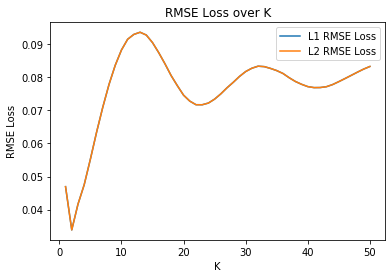

In [384]:
#Used for Q1 to determine the best cross-validation RMSE, the optimal k and the best similarity metric.
#Also used to plot the cross-validation RMSE over values of k.

#To use uncomment desired data set and input the values of k to check over

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=1000, d=2)
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('pumadyn32nm')
k_lower_bound = 1
k_upper_bound = 51
regression(x_train, x_valid, x_test, y_train, y_valid, y_test, k_lower_bound, k_upper_bound)

#Results:

#mauna_loa L1 or L2, k = 2, RMSE = 0.03409887528152139
#rosenbrock L2, k = 2, RMSE = 0.27787357307360205
#pumadyn32nm L1, k = 28, RMSE: 0.872209397081263

Test RMSE: 0.44070489035463933


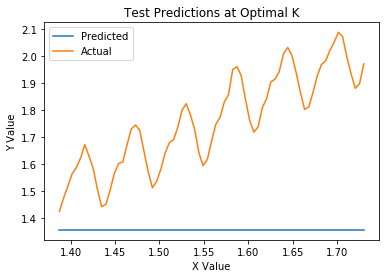

In [383]:
#Used for Q1, to get the Test RMSE for the optimal settings and to plot the test RMSE of the mauna_loa dataset if
#the mauna_loa dataset is used.

#To use, uncomment desired data set, input the value of k to check (question asks for optimal k), input the desired
#similarity metric and set mauna_loa to True if mauna_loa dataset is used otherwise, set mauna_loa to False.

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=1000, d=2)
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('pumadyn32nm')

k = 2
mauna_loa = True
metric = 2
test_regression(x_train, x_valid, x_test, y_train, y_valid, y_test, k, metric, mauna_loa)

#Results:
#mauna loa: Test RMSE: 0.44070489035463933
#rosenbrock: Test RMSE: 0.24759864413329508
#pumadyn32nm: Test RMSE: 0.8318264776794626

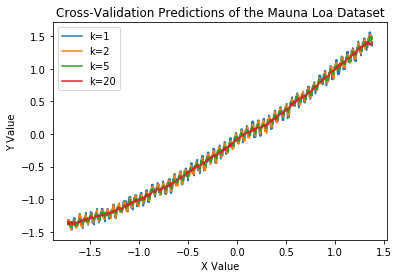

In [370]:
#Used for Q1 to get the merged cross-validation prediction curves of the mauna_loa dataset of several values of k.
#To use, just run the cell or change the numbers in the get_predictions function to plot the cross-validation curves for
#different values of k.

#Load mauna_loa data set and k values to get list of predictions.

x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')

k_1_predictions, k_1_x = get_predictions(1,x_train, x_valid, x_test, y_train, y_valid, y_test)
k_2_predictions, k_2_x = get_predictions(2,x_train, x_valid, x_test, y_train, y_valid, y_test)
k_5_predictions, k_5_x = get_predictions(5,x_train, x_valid, x_test, y_train, y_valid, y_test)
k_20_predictions, k_20_x = get_predictions(20,x_train, x_valid, x_test, y_train, y_valid, y_test)


#Plot predictions for mauna_loa data set.

plt.plot(k_1_x,k_1_predictions)
plt.plot(k_2_x,k_2_predictions)
plt.plot(k_5_x,k_5_predictions)
plt.plot(k_20_x,k_20_predictions)

plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.title('Cross-Validation Predictions of the Mauna Loa Dataset')
plt.legend(['k=1', 'k=2', 'k=5', 'k=20'])


RMSE for Increasing Dimensions
[0.2826298517051506, 0.3964060144579795, 0.4226179836587372, 0.5541281346915816, 0.6207218117365522, 0.6857095048097601, 0.7553856555694677, 0.8017483490670229, 0.8506430613934854, 0.8981899818641472, 0.8983697946682067, 0.9520865320177305, 0.9523117948055555, 0.9681981298143123, 1.0050487441956741, 1.0279507733713036, 1.0288887119811911, 1.066141630016593, 1.0767685650398573, 1.0955911716120628, 1.0981288009790071, 1.1240952844829315, 1.1276233600480026, 1.1314212286725256, 1.141565813347969, 1.1670358848651325, 1.1643471284039575, 1.1668859928042685, 1.1641015899347222]


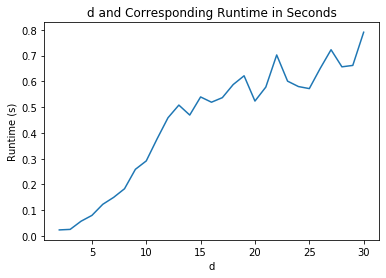

In [277]:
#Used for Q2 to plot d of rosenbrock dataset and corresponding runtime in seconds and to print the RMSE for each dimension.

#To use, change the dimensions of d to plot over in the function.

plot_d_runtime(2,31)

In [399]:
#Used for Q2 to compare the runtime of the brute force algorithm and the KD-Tree algorithm for regression 
#on the rosenbrock data set.
#Prints out the runtimes for the KD-Tree and brute force algorithms.

#To use, just run the cell.

tree_brute_time()

#Result:

#KD Tree Algorithm Time: 0.030648231506347656
#Brute Force Algorithm Time: 0.3912689685821533

KD Tree Algorithm Time: 0.030648231506347656
Brute Force Algorithm Time: 0.3912689685821533


In [401]:
#Used for Q3 to find the best validation accuracy for the classification dataset and the coresponding optimal k and similarity
#metric using k-NN.

#To use, uncomment the desired dataset and input the values of k to check over.

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mnist_small')

k_lower = 1
k_upper = 11
knn_classifier(x_train, x_valid, x_test, y_train, y_valid, y_test, k_lower, k_upper)

#Results

#iris:
#Best similarity metric: l2
#Optimal k: 6
#Validation Accuracy: 0.9032258064516129

#mnist_small:
#Best similarity metric: l2
#Optimal k: 1
#Validation Accuracy: 0.95

Iteration: 1
L1 Accuracy: 0.941
L2 Accuracy: 0.95
Iteration: 2
L1 Accuracy: 0.923
L2 Accuracy: 0.937
Iteration: 3
L1 Accuracy: 0.933
L2 Accuracy: 0.945
Iteration: 4
L1 Accuracy: 0.925
L2 Accuracy: 0.938
Iteration: 5
L1 Accuracy: 0.933
L2 Accuracy: 0.944
Iteration: 6
L1 Accuracy: 0.933
L2 Accuracy: 0.942
Iteration: 7
L1 Accuracy: 0.934
L2 Accuracy: 0.944
Iteration: 8
L1 Accuracy: 0.926
L2 Accuracy: 0.938
Iteration: 9
L1 Accuracy: 0.932
L2 Accuracy: 0.94
Iteration: 10
L1 Accuracy: 0.928
L2 Accuracy: 0.939
Best similarity metric: l2
Optimal k: 1
Validation Accuracy: 0.95


In [373]:
#Used for Q3 to find the test accuracy of the classification datasets.

#To use, uncomment the desired dataset and set a value for k (question asks for optimal k).

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mnist_small')

k = 1
test_classifier(x_train, x_valid, x_test, y_train, y_valid, y_test, k)

#Results

#iris:
#Test Accuracy: 1.0

#mnist_small:
#Test Accuracy: 0.958

Test Accuracy: 0.958


In [402]:
#Used for Q4 to to find the test RMSE for the regression data sets using linear models and SVD.

#To use, uncomment the desired data set.

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=1000, d=2)
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('pumadyn32nm')

SVD_regression(x_train, x_valid, x_test, y_train, y_valid, y_test)

#Results:

#mauna loa RMSE: 0.34938831049910135
#rosenbrock RMSE: 0.98408720306877
#pumadyn32nm RMSE: 0.8622512436598077

RMSE: 0.98408720306877


In [382]:
#Used for Q4 to find the Test Accuracy for the classification data sets using linear models and SVD.

#To use, uncomment the desired data set.

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mnist_small')

SVD_classification(x_train, x_valid, x_test, y_train, y_valid, y_test)

#Results:

#iris: Test Accuracy: 86.66666666666667%
#mnist_small: Test Accuracy: 85.5%

Test Accuracy: 85.5%
